In [1]:
from adaline import Adaline, Stochastic_Adaline

In [2]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import pandas as pd

In [3]:
iris_dataset = load_iris()

In [4]:
df = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
df['target'] = iris_dataset.target

In [5]:
df = df[df.target!=2]
df.target = df.target.apply(lambda x: 1 if x==1 else -1)

In [6]:
df = df.sample(frac=1, random_state=70)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(df.drop('target', axis=1))

xtrain, xtest, y_train, y_test = train_test_split(X, df['target'].to_numpy(), test_size=0.10, random_state=50, stratify= df['target'])

In [8]:
model = Adaline(epochs=70)
model.fit(xtrain, y_train)
y_pred = model.predict(xtest)

Epochs: 0, loss: 49.29
Epochs: 10, loss: 2.32
Epochs: 20, loss: 2.03
Epochs: 30, loss: 1.94
Epochs: 40, loss: 1.89
Epochs: 50, loss: 1.85
Epochs: 60, loss: 1.82


In [9]:
print(f'Accuracy score of the model, {accuracy_score(y_pred, y_test)}')

Accuracy score of the model, 1.0


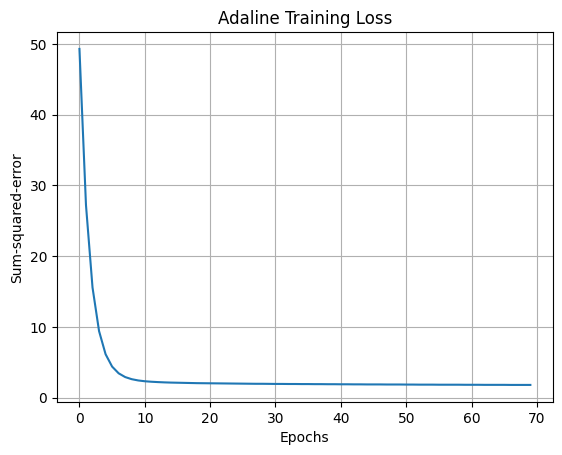

In [10]:
import matplotlib.pyplot as plt

plt.plot(model.costs)
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline Training Loss')
plt.grid(True)
plt.show()

In [11]:
sd_adaline = Stochastic_Adaline()

In [12]:
sd_adaline.fit(xtrain, y_train)

In [13]:
y_pred = sd_adaline.predict(xtest)

In [14]:
accuracy_score(y_pred, y_test)

1.0

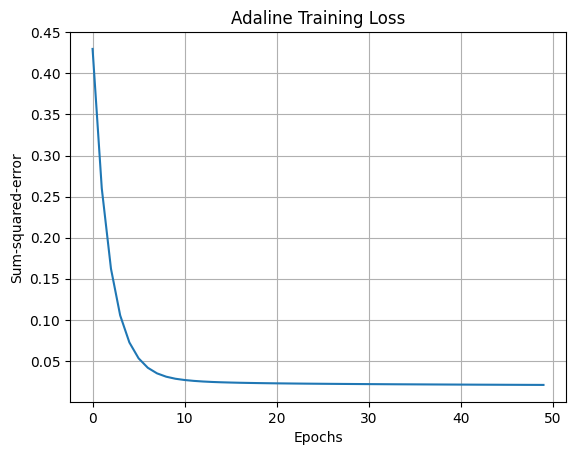

In [15]:
import matplotlib.pyplot as plt

plt.plot(sd_adaline.costs)
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline Training Loss')
plt.grid(True)
plt.show()